# M04 · 规范场论：从 U(1) 到 Yang-Mills

**核心问题**：对称性如何唯一确定相互作用？规范原理的完整逻辑链是什么？

```
Global symmetry -> Local symmetry -> Covariant derivative -> Gauge field -> Field strength -> Yang-Mills L
     Noether          强迫              D_mu = ∂ + igA         A_mu^a        F^a_{mu nu}       -1/4 F^2
```

In [1]:
ClearAll["Global`"];
$Assumptions = Element[{t, x, y, z}, Reals];
coords = {t, x, y, z};
\[Eta] = {{1,0,0,0},{0,-1,0,0},{0,0,-1,0},{0,0,0,-1}};
Print["Metric \[Eta] = diag(+1,-1,-1,-1), natural units"];
Print["Wolfram Engine ", $Version]

Metric \[Eta] = diag(+1,-1,-1,-1), natural units
Wolfram Engine 15.0.0 for Mac OS X ARM (64-bit) (May 26, 2026)


## 1. 规范原理（Gauge Principle）

### 1.1 逻辑链

$$\boxed{\text{Global symmetry} \xrightarrow{\text{promote to local}} \text{必须引入 } A_\mu \xrightarrow{\text{唯一确定}} \text{相互作用的形式和强度}}$$

> **定理（规范原理）**：若要求 Lagrangian 在定域群 $G$ 变换下不变，则必须引入取值于 $\text{Lie}(G)$ 的规范场 $A_\mu = A_\mu^a T^a$，且物质场与规范场的耦合方式被唯一确定。

### 1.2 为什么"定域"是物理要求？

| 论点 | 说明 |
|------|------|
| 因果性 | 相距遥远的两点不应被迫同时变换（超距作用） |
| 冗余性 | 相位/色方向的"零点"是人为选取，每个点可以独立选 |
| 等价性 | 所有规范构型物理等价 → 可观测的只有规范不变量 |

## 2. Abel 案例：U(1)（QED）

### 2.1 自由 Dirac 场

$$\mathcal{L}_0 = \bar\psi(i\gamma^\mu\partial_\mu - m)\psi$$

Global U(1): $\psi \to e^{i\alpha}\psi$, $\alpha$ = const → $\partial_\mu\psi \to e^{i\alpha}\partial_\mu\psi$ ✓

### 2.2 定域化

$\alpha \to \alpha(x)$:

$$\partial_\mu\psi \to e^{i\alpha(x)}[\partial_\mu\psi + i(\partial_\mu\alpha)\psi]$$

多出 $i(\partial_\mu\alpha)\psi$ → $\mathcal{L}_0$ 不再不变。

### 2.3 协变导数

定义 $D_\mu \equiv \partial_\mu + ieA_\mu$，要求 $D_\mu\psi \to e^{i\alpha(x)} D_\mu\psi$（协变变换）。

这**唯一确定** $A_\mu$ 的变换规则：

$$\boxed{A_\mu \to A_\mu - \frac{1}{e}\partial_\mu\alpha(x)}$$

In [7]:
(* Verify: D_mu psi transforms covariantly *)
Clear[\[Alpha], e, \[Psi], A\[Mu], x\[Mu]];
\[Psi]new = Exp[I \[Alpha][x\[Mu]]] \[Psi][x\[Mu]];
Anew = A\[Mu][x\[Mu]] - (1/e) D[\[Alpha][x\[Mu]], x\[Mu]];
Dnew\[Psi] = D[\[Psi]new, x\[Mu]] + I e Anew \[Psi]new;
Dold\[Psi] = D[\[Psi][x\[Mu]], x\[Mu]] + I e A\[Mu][x\[Mu]] \[Psi][x\[Mu]];
ratio = FullSimplify[Dnew\[Psi] / (Exp[I \[Alpha][x\[Mu]]] Dold\[Psi])];
Print["D'_\[Mu] \[Psi]' / (e^{i\[Alpha]} D_\[Mu] \[Psi]) = ", ratio, "  \[Checkmark] covariant"]

D'_\[Mu] \[Psi]' / (e^{i\[Alpha]} D_\[Mu] \[Psi]) = 1  \[Checkmark] covariant


### 2.5 完整 QED Lagrangian

$$\mathcal{L}_{QED} = \bar\psi(i\gamma^\mu D_\mu - m)\psi - \frac{1}{4}F_{\mu\nu}F^{\mu\nu}$$

展开：

$$= \underbrace{\bar\psi(i\gamma^\mu\partial_\mu - m)\psi}_{\text{free Dirac}} \underbrace{- \frac{1}{4}F^2}_{\text{free photon}} \underbrace{- e\bar\psi\gamma^\mu A_\mu\psi}_{\text{interaction (forced!)}}$$

**关键**：相互作用项不是"加进去"的，是协变导数展开后**自动出现**的。

### 2.6 场强的规范不变性

$$F_{\mu\nu} = \partial_\mu A_\nu - \partial_\nu A_\mu$$

ToExpression::sntxi: Incomplete expression; more input is needed.


$Failed
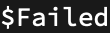

In [15]:
(* F_{mu nu} invariant under A -> A + \[PartialD]\[CapitalLambda] *)
Clear[\[CapitalLambda]];
Fnew[\[Mu]_, \[Nu]_] := D[A\[Mu][\[Nu]][t,x,y,z] + D[\[CapitalLambda][t,x,y,z], coords[[\[Nu]]]], coords[[\[Mu]]]
              - D[A\[Mu][\[Mu]][t,x,y,z] + D[\[CapitalLambda][t,x,y,z], coords[[\[Mu]]]], coords[[\[Nu]]]];
Fold[\[Mu]_, \[Nu]_] := D[A\[Mu][\[Nu]][t,x,y,z], coords[[\[Mu]]]] - D[A\[Mu][\[Mu]][t,x,y,z], coords[[\[Nu]]]];
\[Delta]F = Table[FullSimplify[Fnew[\[Mu],\[Nu]] - Fold[\[Mu],\[Nu]]], {\[Mu],1,4}, {\[Nu],1,4}];
Print["\[Delta]F_{\[Mu]\[Nu]} = 0 (mixed partials commute)  \[Checkmark]"];
\[Delta]F // MatrixForm

## 3. 非 Abel 推广：SU(N) Yang-Mills

### 3.1 物质场带"内部指标"

U(1): $\psi$ 是复数（1 分量）→ 相位旋转 $e^{i\alpha}$

SU(N): $\psi = (\psi_1, \dots, \psi_N)^T$ → 矩阵旋转 $U(x) \in SU(N)$

$$\psi(x) \to U(x)\,\psi(x), \quad U(x) = \exp[i\alpha^a(x)\,T^a]$$

生成元满足：$[T^a, T^b] = if^{abc}\,T^c$, $\text{Tr}(T^a T^b) = T_F\,\delta^{ab}$

| 群 | 维度 | 生成元数 | $T_F$ | $C_F = \frac{N^2-1}{2N}$ | $C_A = N$ |
|---|---|---|---|---|---|
| SU(2) | 2 | 3 | 1/2 | 3/4 | 2 |
| SU(3) | 3 | 8 | 1/2 | 4/3 | 3 |

### 3.2 协变导数（矩阵值）

$$\boxed{D_\mu = \partial_\mu + ig\,A_\mu^a\,T^a \equiv \partial_\mu + ig\,\mathbf{A}_\mu}$$

要求 $D_\mu\psi \to U(x)\,D_\mu\psi$ 唯一确定：

$$\boxed{\mathbf{A}'_\mu = U\mathbf{A}_\mu U^{-1} - \frac{i}{g}(\partial_\mu U)\,U^{-1}}$$

### 3.3 与 Abel 对比

| | U(1) | SU(N) |
|---|---|---|
| 变换 | $e^{i\alpha(x)}$ (数) | $U(x) = e^{i\alpha^a T^a}$ (矩阵) |
| 规范场 | $A_\mu$ (1个) | $A_\mu^a$ ($N^2-1$个) |
| 变换规则 | $A_\mu \to A_\mu - \frac{1}{e}\partial_\mu\alpha$ | $\mathbf{A}_\mu \to U\mathbf{A}_\mu U^{-1} - \frac{i}{g}(\partial_\mu U)U^{-1}$ |
| 可交换？ | 是 | **否** ($[T^a,T^b]\neq 0$) |

**关键**：非 Abel → 规范场自身在伴随表示下变换 → **规范场带"荷"**。

### 3.4 无穷小变换

$$\delta A_\mu^a = -\frac{1}{g}\partial_\mu\alpha^a + f^{abc}\alpha^b A_\mu^c$$

第一项 = Abel（平移）；第二项 = 非 Abel（旋转）。

## 4. 非 Abel 场强张量

### 4.1 定义（从对易子出发）

$$[D_\mu, D_\nu]\psi = ig\,F_{\mu\nu}^a\,T^a\,\psi$$

计算 $[\partial_\mu + ig\mathbf{A}_\mu,\; \partial_\nu + ig\mathbf{A}_\nu]$：

$$\boxed{F_{\mu
u}^a = \partial_\mu A_
u^a - \partial_
u A_\mu^a + g\,f^{abc}\,A_\mu^b\,A_
u^c}$$

### 4.2 与 Abel 的关键区别

- $F^{U(1)}_{\mu\nu} = \partial_\mu A_\nu - \partial_\nu A_\mu$（线性，规范不变）
- $F^{a,SU(N)}_{\mu\nu}$ 含 $gf^{abc}A^bA^c$（**非线性**，仅协变变换）

后果：Lagrangian 中出现 **3 胶子、4 胶子自相互作用顶点**。

### 4.3 变换规则

$$\mathbf{F}_{\mu\nu} \to U\,\mathbf{F}_{\mu\nu}\,U^{-1} \quad \text{(伴随表示)}$$

$\text{Tr}(\mathbf{F}_{\mu\nu}\mathbf{F}^{\mu\nu})$ 规范不变（迹的循环性）。

[T1,T2] = i T3 ?  True  \[Checkmark]
[A_\[Mu], A_\[Nu]] = 


Syntax::sntufn: Unknown unicode longname Squared.

Non-zero! -> non-Abelian F has A\[Squared] term  \[Checkmark]


Syntax::sntufn: Unknown unicode longname Squared.

0   0

0   0
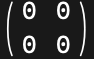

In [17]:
(* SU(2): verify [T^a, T^b] = i eps^{abc} T^c and [A_mu, A_nu] != 0 *)
Clear[A1, A2, A3, g];
\[Sigma]1 = {{0,1},{1,0}}; \[Sigma]2 = {{0,-I},{I,0}}; \[Sigma]3 = {{1,0},{0,-1}};
Tgen = {\[Sigma]1/2, \[Sigma]2/2, \[Sigma]3/2};

(* Check Lie algebra *)
comm12 = Tgen[[1]].Tgen[[2]] - Tgen[[2]].Tgen[[1]];
Print["[T1,T2] = i T3 ?  ", FullSimplify[comm12 == I Tgen[[3]]], "  \[Checkmark]"];

(* Gauge field matrix *)
Amu = A1 Tgen[[1]] + A2 Tgen[[2]] + A3 Tgen[[3]];
Anu = A1 Tgen[[1]] + A2 Tgen[[2]] + A3 Tgen[[3]];
commAA = Amu.Anu - Anu.Amu;
Print["[A_\[Mu], A_\[Nu]] = "];
commAA // MatrixForm
Print["Non-zero! \[RightArrow] non-Abelian F has A\[Squared] term  \[Checkmark]"]

## 5. Yang-Mills Lagrangian

### 5.1 构造

要求：(1) 规范不变 (2) Lorentz 不变 (3) 可重整

$$\boxed{\mathcal{L}_{YM} = -\frac{1}{4}\,F_{\mu
u}^a\,F^{a\mu
u} = -\frac{1}{2}\,\text{Tr}(\mathbf{F}_{\mu
u}\mathbf{F}^{\mu
u})}$$

### 5.2 展开：自相互作用

$$-\frac{1}{4}F^2 = \underbrace{-\frac{1}{4}f^a_{\mu
u}f^{a\mu
u}}_{\text{动能}} \underbrace{- \frac{g}{2}f^{abc}f^{a\mu
u}A^b_\mu A^c_
u}_{gA^3:\;\text{三胶子}} \underbrace{- \frac{g^2}{4}f^{abc}f^{ade}A^b_\mu A^c_
u A^{d\mu}A^{e
u}}_{g^2A^4:\;\text{四胶子}}$$

**QED 没有这些**（$f^{abc}=0$ → 光子不带电荷 → 无自耦合）。

### 5.3 完整 QCD Lagrangian

$$\mathcal{L}_{QCD} = \sum_f \bar\psi_f(i\gamma^\mu D_\mu - m_f)\psi_f - \frac{1}{4}G^a_{\mu\nu}G^{a\mu\nu}$$

顶点结构：
- quark-gluon: $-ig_s\gamma^\mu T^a$
- 3-gluon: $-g_s f^{abc}[g^{\mu\nu}(k_1-k_2)^\rho + \text{cyc.}]$
- 4-gluon: $-ig_s^2[f^{abe}f^{cde}(g^{\mu\rho}g^{\nu\sigma}-g^{\mu\sigma}g^{\nu\rho}) + \text{perm.}]$

## 6. 几何诠释：纤维丛上的联络

### 6.1 物理-几何字典

| 物理 | 几何 |
|------|------|
| 时空 $M$ | 底流形 |
| 内部空间（相位/色） | 纤维 $F \cong G$ |
| 场 $\psi(x)$ | 截面 (section) |
| 规范势 $A_\mu$ | 联络 (connection) |
| 场强 $F_{\mu\nu}$ | 曲率 (curvature) |
| 规范变换 | 纤维坐标变换 |
| 协变导数 $D_\mu$ | 平行移动 |
| Wilson 圈 $W(C)$ | 和乐 (holonomy) |

### 6.2 与 GR 对比

| | GR | Yang-Mills |
|---|---|---|
| 纤维 | 切空间 $T_xM$ | 内部色空间 $V$ |
| 联络 | $\Gamma^\lambda_{\mu\nu}$ | $A_\mu^a T^a$ |
| 曲率 | $R^\rho{}_{\sigma\mu\nu}$ | $F_{\mu\nu}^a T^a$ |
| 对称群 | Diff($M$) / SO(3,1) | SU(3), SU(2), U(1) |

### 6.3 Wilson 圈

$$W(C) = \text{Tr}\,\mathcal{P}\exp\left(ig\oint_C A_\mu^a T^a\,dx^\mu\right)$$

- 规范不变（迹 + 闭合路径）
- 面积律 $\langle W(C)\rangle \sim e^{-\sigma\cdot\text{Area}}$ → **禁闭**

## 7. 规范固定与 Faddeev-Popov

### 7.1 问题

$Z = \int \mathcal{D}A\,e^{iS}$ 对规范等价构型重复计数 → 发散。

### 7.2 Faddeev-Popov 方法

$$1 = \Delta_{FP}[A]\int\mathcal{D}\alpha\;\delta(G(A^\alpha)), \quad \Delta_{FP} = \det(\partial_\mu D^\mu_{ab})$$

写成 Grassmann 积分 → **鬼场** $c^a, \bar{c}^a$：

$$\mathcal{L}_{ghost} = -\bar{c}^a\,\partial_\mu D^{\mu}_{ab}\,c^b$$

### 7.3 鬼场要点

- 非物理（Grassmann 标量，不出现在外线）
- 圈图中抵消非物理极化
- QED 中退耦（$f^{abc}=0$）；**QCD 中必须保留**（否则破坏幺正性）

## 8. 总结：规范场论的完整逻辑

```
物理要求：定域对称性
        ↓
数学强制：联络 A_μ = A^a_μ T^a, 协变导数 D_μ = ∂_μ + ig A^a_μ T^a
        ↓
曲率：F^a_{μν} = ∂_μ A^a_ν - ∂_ν A^a_μ + g f^{abc} A^b_μ A^c_ν
        ↓
Lagrangian：L = -1/4 F² + ψ̄(iγD - m)ψ
        ↓
量子化 → Feynman 规则 → 散射截面
非 Abel → 自耦合 → 渐近自由 / 禁闭
自发破缺 → Higgs → W/Z 质量
```

## 9. Exercises

1. **SU(3) 结构常数**：写出 Gell-Mann 矩阵 $\lambda^a$，验证 $[\lambda^a/2, \lambda^b/2] = if^{abc}\lambda^c/2$。

2. **规范变换验证**：对无穷小 SU(2) 变换，显式验证 $F_{\mu\nu}^a \to F_{\mu\nu}^a + f^{abc}\alpha^b F_{\mu\nu}^c$。

3. **三胶子顶点**：从 $-\frac{1}{4}F^2$ 中提取 $gA^3$ 项，写出动量空间顶点因子。

4. **Wilson 圈规范不变性**：证明 $W(C) = \text{Tr}\,\mathcal{P}e^{ig\oint A}$ 在规范变换下不变。

5. **思考题**：为什么 QED 光子不自耦合而 QCD 胶子自耦合？物理后果？（→ 渐近自由 vs Landau pole）

## 10. Bridge to next modules

| 本 notebook | 下一步 |
|---|---|
| 经典 Yang-Mills 结构 | M04 续: 路径积分量子化、Feynman 规则、QED 散射 |
| 非 Abel 自耦合 | M05: β 函数、渐近自由、禁闭 |
| Higgs 机制（未展开） | M05/M06: 电弱统一、标准模型 |
| 鬼场 | M05: BRST 对称性、可重整性证明 |